# Lab 2 — Forest Loss / Gain ด้วย ESRI 10 m Land Cover (GEE + geemap)

ชุดข้อมูล: ESRI / Impact Observatory 10 m Annual LULC time-series
(อ้างอิง https://livingatlas.arcgis.com/landcover/ , เข้าถึงผ่าน https://gee-community-catalog.org/projects/S2TSLULC/)

**โน้ตบุ๊กนี้เป็นเวอร์ชันที่ปรับปรุงจากไฟล์ต้นฉบับของวิชา** โดยตั้งใจ *ไม่* ไล่ให้ accuracy สูงที่สุด
แต่เน้น (1) ทำให้โค้ดรันได้จริง (2) ชี้จุดที่ผิด/บิดเบือนตัวเลข พร้อมเหตุผล (3) ออกแบบกระบวนการที่อธิบายได้

---

## สรุปจุดที่ตรวจพบในไฟล์ต้นฉบับ และการแก้

| # | จุดที่เป็นปัญหา (ไฟล์เดิม) | ผลกระทบ | สิ่งที่ทำในเวอร์ชันนี้ |
|---|---|---|---|
| 1 | เซลล์ `Map.ts_inspector(...)` เรียกใช้ตัวแปร `esri_vis` ที่ **ไม่เคยถูกประกาศ** | `NameError` รันไม่ผ่าน | ประกาศ `esri_vis` ให้ครบ (min=1, max=11, palette 11 สี ตามรหัสคลาสจริง) |
| 2 | `Map.ts_inspector(collection, years, esri_vis, width=...)` ส่งอาร์กิวเมนต์แบบ positional | geemap รุ่นใหม่ signature คือ `(left_ts, right_ts, left_names, ...)` → `years` ถูกตีความเป็น right_ts | เรียกด้วย keyword argument + `try/except` fallback เป็น `split_map` |
| 3 | `years_int = list(range(2017, 2024))` ฮาร์ดโค้ดปี | ชุดข้อมูลมีถึงปี 2024–2025 แล้ว (และถ้าปีไหนว่าง `mosaic()` จะคืนภาพเปล่าแบบเงียบ ๆ) | อ่านปีที่มีจริงจาก collection แล้วรายงานจำนวนภาพต่อปีก่อนใช้ |
| 4 | `filterDate(f'{y}-01-01', f'{y}-12-31')` | ปลายช่วงเป็น exclusive → เสี่ยงตกภาพวันสุดท้าย | ใช้ `f'{y}-01-01'` ถึง `f'{y+1}-01-01'` |
| 5 | ไม่ได้ `filterBounds` ก่อน `mosaic()` | mosaic ทั้งโลกทุกปี = งานหนักเกินจำเป็น | `filterBounds(thailand)` ก่อนเสมอ |
| 6 | คำนวณ loss/gain จาก **ปีเดียวเทียบปีเดียว** และไม่กรอง no-data / คลาส Clouds (10) | pixel ที่ปีหนึ่งถูกทำนายเป็นเมฆ/ว่าง จะกลายเป็น "ป่าหาย" หรือ "ป่าเพิ่ม" ปลอม | เพิ่ม `valid mask` (ตัดคลาส 0 และ 10 ทั้งสองปี) + โหมด **strict** ที่ต้องเป็นป่า/ไม่ป่า *ติดกัน 2 ปี* ที่หัวและท้ายช่วง |
| 7 | ไม่มีการกรอง salt-and-pepper (pixel เดี่ยว ๆ) | แผนที่ AI ระดับ 10 m มีจุดรบกวนเยอะ ทำให้ตัวเลขพื้นที่พองเกินจริง | เพิ่ม MMU ด้วย `connectedPixelCount` (ตัด patch เล็กกว่า N pixel) เปิด/ปิดได้ |
| 8 | `reduceRegion(..., scale=100, bestEffort=True)` บนข้อมูล 10 m | (ก) scale 100 = สุ่มอ่านค่า 1 ใน 100 pixel ทำให้พื้นที่ที่กระจัดกระจายคลาดเคลื่อนมาก (ข) `bestEffort=True` GEE จะ **ขยาย scale เองเงียบ ๆ** ถ้าพื้นที่ใหญ่ ตัวเลขที่ได้จึงไม่ใช่ scale 100 อย่างที่คิด | ตั้ง `bestEffort=False` + `tileScale` และทำ **ตารางทดสอบความไวต่อ scale** (10 / 30 / 100 m) ให้เห็นว่าตัวเลขเปลี่ยนแค่ไหน |
| 9 | `ee.Number(a.values().get(0))` | ดึงค่าจาก dict โดยอิงลำดับ key ซึ่งไม่การันตี | `rename('area')` แล้ว `.get('area')` |
| 10 | ตารางปลายทางใช้ `frequencyHistogram` แล้วคูณ `100*100/1600` | สมมติว่า pixel = 100×100 m เป๊ะ ซึ่งไม่จริงเมื่อ bestEffort เปลี่ยน scale และไม่จริงเชิงพื้นที่จริงบนทรงรี | ใช้ `ee.Reducer.sum().group()` บน `ee.Image.pixelArea()` → ได้พื้นที่จริงเป็น ตร.ม. ตรง ๆ |
| 11 | สีเลเยอร์: ป่า = `'#ab6c28'` / `'brown'` | สื่อสารผิด (น้ำตาล = ดินเปล่า) | ใช้เขียวสำหรับป่า, แดง = loss, ฟ้า = gain |
| 12 | `FAO/GAUL/2015/level1` | ชั้นข้อมูลนี้ถูกขึ้นสถานะ deprecated ใน GEE catalog และผู้ใช้บางบัญชีเข้าไม่ได้ | ลองหลายแหล่งตามลำดับ + พิมพ์รายชื่อจังหวัดให้เห็น กันสะกดผิด |
| 13 | ไม่มีการตรวจสอบผล (validation) เลย | ตัวเลขไม่มีน้ำหนัก | เพิ่มการสุ่มจุดในพื้นที่ loss พร้อมลิงก์ Google Maps ไว้ตรวจด้วยตา |
| 14 | ดูแค่ 2 ปีหัว-ท้าย | ไม่เห็นว่าเป็นแนวโน้มจริงหรือ noise | เพิ่มกราฟพื้นที่ป่ารายปีทั้งช่วง |

> **ข้อควรระวังเชิงความหมาย:** คลาส `Trees` ของ ESRI = "พื้นที่ที่มีเรือนยอดไม้" ซึ่งรวม **ยางพารา ปาล์ม สวนผลไม้ ป่าปลูก** ไม่ใช่นิยาม "ป่าไม้" ตามกฎหมาย/กรมป่าไม้ ตัวเลขในแลปนี้จึงเทียบตรง ๆ กับสถิติราชการไม่ได้

## 1. ติดตั้ง / เชื่อมต่อ Earth Engine

ถ้ารันบน Google Colab: `geemap` มักต้องติดตั้งเอง (uncomment บรรทัดแรก)
`project=` ต้องเปลี่ยนเป็น Cloud Project ID ของนักศึกษาเอง (ดูมุมขวาบนของ GEE Code Editor)

In [2]:
# !pip install -q geemap earthengine-api

import ee, geemap, math, time
import pandas as pd

PROJECT_ID = 'ee-suranajkrua165'   # <<<< แก้ตรงนี้

try:
    ee.Initialize(project=PROJECT_ID)
except Exception as e:
    print('ยังไม่ได้ authenticate หรือ project ผิด -> จะเปิดหน้า login ให้')
    ee.Authenticate()
    ee.Initialize(project=PROJECT_ID)

print('Earth Engine พร้อมใช้งาน | geemap', geemap.__version__)

ยังไม่ได้ authenticate หรือ project ผิด -> จะเปิดหน้า login ให้
Earth Engine พร้อมใช้งาน | geemap 0.38.3


## 2. ขอบเขตพื้นที่ศึกษา (ประเทศไทย + จังหวัด)

ไฟล์เดิมใช้ `FAO/GAUL/2015/level1` ซึ่งถูกประกาศ deprecated ในแคตตาล็อกของ GEE
เวอร์ชันนี้จึงไล่ลองหลายชั้นข้อมูลตามลำดับ และ **พิมพ์รายชื่อจังหวัดออกมา** เพื่อกันปัญหาสะกดชื่อไม่ตรง
(ถ้าได้ 0 feature = ชื่อผิด ไม่ใช่ข้อมูลไม่มี)

In [3]:
thailand = (ee.FeatureCollection('USDOS/LSIB_SIMPLE/2017')
            .filter(ee.Filter.eq('country_na', 'Thailand')))

ADM_CANDIDATES = [
    'FAO/GAUL_SIMPLIFIED_500m/2015/level1',
    'FAO/GAUL/2015/level1',
]

adm1, ADM_SOURCE = None, None
for path in ADM_CANDIDATES:
    try:
        fc = ee.FeatureCollection(path).filter(ee.Filter.eq('ADM0_NAME', 'Thailand'))
        n = fc.size().getInfo()
        if n > 0:
            adm1, ADM_SOURCE = fc, path
            print(f'ใช้ขอบเขตจังหวัดจาก: {path}  (จำนวน {n} หน่วย)')
            break
    except Exception as e:
        print(f'เข้าไม่ได้: {path} -> {type(e).__name__}')

prov_names = sorted(adm1.aggregate_array('ADM1_NAME').getInfo())
print('\nตัวอย่างชื่อจังหวัดที่สะกดได้ (ต้องสะกดตรงกับนี้):')
print(prov_names)

ใช้ขอบเขตจังหวัดจาก: FAO/GAUL_SIMPLIFIED_500m/2015/level1  (จำนวน 76 หน่วย)

ตัวอย่างชื่อจังหวัดที่สะกดได้ (ต้องสะกดตรงกับนี้):
['Amnat Charoen', 'Ang Thong', 'Bangkok', 'Buriram', 'Chachoengsao', 'Chainat', 'Chaiyaphum', 'Chanthaburi', 'Chiang Mai', 'Chiang Rai', 'Chonburi', 'Chumphon', 'Kalasin', 'Kampaeng Phet', 'Kanchanaburi', 'Khon Kaen', 'Krabi', 'Lampang', 'Lamphun', 'Loei', 'Lopburi', 'Mae Hong Son', 'Maha Sarakham', 'Mukdahan', 'Nakhon Nayok', 'Nakhon Pathom', 'Nakhon Phanom', 'Nakhon Ratchasima', 'Nakhon Sawan', 'Nakhon Si Thammarat', 'Nan', 'Narathiwat', 'Nong Bua Lamphu', 'Nong Khai', 'Nonthaburi', 'Pathum Thani', 'Pattani', 'Phachinburi', 'Phangnga', 'Phatthalung', 'Phayao', 'Phetchabun', 'Phetchaburi', 'Phichit', 'Phitsanulok', 'Phra Nakhon Si Ayudhya', 'Phrae', 'Phuket', 'Prachuap Khilikhan', 'Ranong', 'Ratchaburi', 'Rayong', 'Roi Et', 'Sa Kaeo', 'Sakon Nakhon', 'Samut Prakarn', 'Samut Sakhon', 'Samut Songkham', 'Saraburi', 'Satun', 'Si Saket', 'Singburi', 'Songkhla', 'S

## 3. โหลด ESRI 10 m LULC time-series และ **ตรวจว่ามีปีอะไรบ้างจริง ๆ**

จุดที่ไฟล์เดิมพลาด: ฮาร์ดโค้ด `range(2017, 2024)` ทั้งที่ collection ถูกอัปเดตเพิ่มปีเรื่อย ๆ
และถ้าปีไหนไม่มีภาพ `.mosaic()` จะคืน "ภาพเปล่า" โดยไม่ error — บั๊กจะไปโผล่ตอนคำนวณพื้นที่แล้วได้ 0 แบบงง ๆ
ที่นี่จึงนับจำนวนภาพต่อปี (เฉพาะที่ตัดกับประเทศไทย) ก่อนตัดสินใจ

In [4]:
esri = ee.ImageCollection('projects/sat-io/open-datasets/landcover/ESRI_Global-LULC_10m_TS')
esri_th = esri.filterBounds(thailand)      # สำคัญ: กันไม่ให้ไป mosaic ทั้งโลก

PROBE = list(range(2017, 2027))
sizes = ee.List([esri_th.filterDate(f'{y}-01-01', f'{y+1}-01-01').size() for y in PROBE]).getInfo()

avail = {y: n for y, n in zip(PROBE, sizes)}
print('จำนวนภาพ (tile) ที่ครอบคลุมไทย ต่อปี:')
for y, n in avail.items():
    print(f'  {y}: {n}')

years_int = [y for y, n in avail.items() if n > 0]
print('\nปีที่ใช้ได้จริง:', years_int)
assert len(years_int) >= 2, 'ต้องมีอย่างน้อย 2 ปีจึงจะทำ change detection ได้'

จำนวนภาพ (tile) ที่ครอบคลุมไทย ต่อปี:
  2017: 6
  2018: 6
  2019: 6
  2020: 6
  2021: 6
  2022: 6
  2023: 6
  2024: 6
  2025: 6
  2026: 0

ปีที่ใช้ได้จริง: [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


In [5]:
# ภาพรายปี: mosaic ของ tile ในปีนั้น + ตั้งชื่อ band ให้แน่นอน + ติด property ปีไว้ใช้ต่อ
def yearly_image(y):
    img = (esri_th.filterDate(f'{y}-01-01', f'{y+1}-01-01')
           .mosaic().rename('lulc'))
    return img.set({'year': y, 'system:time_start': ee.Date.fromYMD(y, 1, 1).millis()})

LULC = {y: yearly_image(y) for y in years_int}
collection = ee.ImageCollection([LULC[y] for y in years_int])
years = [str(y) for y in years_int]

print('band ของภาพปีแรก:', LULC[years_int[0]].bandNames().getInfo())

band ของภาพปีแรก: ['lulc']


## 4. พารามิเตอร์การแสดงผล (`esri_vis`) — ตัวแปรที่หายไปในไฟล์เดิม

ESRI/Impact Observatory เวอร์ชัน 9 คลาส ใช้รหัสแบบ **ไม่ต่อเนื่อง** (ไม่มี 3 กับ 6 เพราะ Grass+Scrub ถูกยุบรวมเป็น Rangeland = 11)
เวลาใส่ palette แบบ min/max ต้องใส่สีให้ครบ 11 ช่อง โดยช่อง 3 และ 6 เป็นสีหลอก (placeholder) ที่ไม่มีวันถูกใช้

In [6]:
CLASS_NAMES = {1:'Water', 2:'Trees', 4:'Flooded Vegetation', 5:'Crops',
               7:'Built Area', 8:'Bare Ground', 9:'Snow/Ice', 10:'Clouds', 11:'Rangeland'}

CLASS_COLORS = {1:'#1A5BAB', 2:'#358221', 4:'#87D19E', 5:'#FFDB5C',
                7:'#ED022A', 8:'#EDE9E4', 9:'#F2FAFF', 10:'#C8C8C8', 11:'#C6AD8D'}

# palette ต้องเรียงตามค่า 1..11 ; ค่า 3 และ 6 ไม่มีจริง ใส่สีดำไว้เป็น placeholder
palette = [CLASS_COLORS.get(i, '#000000') for i in range(1, 12)]
esri_vis = {'min': 1, 'max': 11, 'palette': palette}

legend_dict = {f'{k} {v}': CLASS_COLORS[k] for k, v in CLASS_NAMES.items()}
print(esri_vis)

{'min': 1, 'max': 11, 'palette': ['#1A5BAB', '#358221', '#000000', '#87D19E', '#FFDB5C', '#000000', '#ED022A', '#EDE9E4', '#F2FAFF', '#C8C8C8', '#C6AD8D']}


## 5. ไทม์สไลเดอร์เปรียบเทียบรายปี

ไฟล์เดิมเรียก `Map.ts_inspector(collection, years, esri_vis, width='80px')` แบบ positional
แต่ geemap รุ่นปัจจุบัน signature คือ `ts_inspector(left_ts, right_ts=None, left_names=None, right_names=None, left_vis={}, right_vis={}, ...)`
→ `years` จะถูกตีความเป็น `right_ts` ทำให้พังหรือแสดงผลผิด **แก้โดยใช้ keyword argument เสมอ**

In [7]:
Map = geemap.Map(center=[15.0, 101.0], zoom=6)
Map.add_basemap('HYBRID')

try:
    Map.ts_inspector(left_ts=collection, right_ts=collection,
                     left_names=years, right_names=years,
                     left_vis=esri_vis, right_vis=esri_vis)
except Exception as e:
    print('ts_inspector ใช้ไม่ได้ในเวอร์ชันนี้ ->', type(e).__name__, '| ใช้ split_map แทน')
    left  = geemap.ee_tile_layer(LULC[years_int[0]],  esri_vis, years[0])
    right = geemap.ee_tile_layer(LULC[years_int[-1]], esri_vis, years[-1])
    Map.split_map(left, right)

Map.add_legend(title='ESRI Land Cover', legend_dict=legend_dict)
Map

Map(center=[15.0, 101.0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=Dropdown(layo…

## 6. ตั้งค่าการวิเคราะห์

ปรับ 4 ตัวนี้แล้วรันเซลล์ถัดไปใหม่ได้ทั้งหมด — เอาไว้ทดลองว่าผลลัพธ์ "ไวต่อสมมติฐาน" แค่ไหน

In [8]:
PROVINCE  = 'Nan'          # เปลี่ยนเป็นจังหวัดของตัวเอง (สะกดตามลิสต์ในเซลล์ที่ 2)
YEAR_A    = years_int[0]   # ปีตั้งต้น
YEAR_B    = years_int[-1]  # ปีเปรียบเทียบ
SCALE     = 30             # ความละเอียดที่ใช้คำนวณพื้นที่ (m) 10 = ตรงตามข้อมูล แต่ช้ามาก
STRICT    = True           # True = ต้องเป็นป่า/ไม่ป่าติดกัน 2 ปี ที่หัวและท้ายช่วง (ลด noise)
USE_MMU   = True           # True = ตัด patch เล็กกว่า MIN_PIXELS ทิ้ง
MIN_PIXELS = 5             # นับเป็น pixel ที่ 'SCALE' ที่ใช้คำนวณ (ที่ 30 m -> 5 px ≈ 4,500 ตร.ม. ≈ 2.8 ไร่)

prov = adm1.filter(ee.Filter.eq('ADM1_NAME', PROVINCE))
n_prov = prov.size().getInfo()
print(f'พบ feature ของจังหวัด {PROVINCE}: {n_prov} (ต้องได้ 1)')
assert n_prov == 1, 'สะกดชื่อจังหวัดไม่ตรงกับลิสต์ ADM1_NAME'

prov_geom = prov.geometry()
prov_area_rai = prov_geom.area(maxError=100).divide(1600).getInfo()
print(f'พื้นที่จังหวัดตามขอบเขต GAUL ≈ {prov_area_rai:,.0f} ไร่')
print(f'ช่วงเวลาที่วิเคราะห์: {YEAR_A} -> {YEAR_B} | SCALE={SCALE} m | STRICT={STRICT} | MMU={USE_MMU}')

พบ feature ของจังหวัด Nan: 1 (ต้องได้ 1)
พื้นที่จังหวัดตามขอบเขต GAUL ≈ 7,673,358 ไร่
ช่วงเวลาที่วิเคราะห์: 2017 -> 2025 | SCALE=30 m | STRICT=True | MMU=True


## 7. ออกแบบการตรวจจับการเปลี่ยนแปลง

**ปัญหาของวิธีในไฟล์เดิม** (`first.eq(2) AND last.neq(2)`):

1. `neq(2)` เป็นจริงกับ **คลาส Clouds (10)** และกับ pixel ที่ไม่มีข้อมูลด้วย → ปีไหนที่โมเดลทำนายเป็นเมฆ จะถูกนับเป็น "ป่าหาย" ทันที
2. เทียบแค่ 2 ปี → การกระพริบของโมเดล (ปีนี้ Trees ปีหน้า Rangeland ปีถัดไป Trees อีก) กลายเป็นการเปลี่ยนแปลงถาวรในสายตาเรา
3. ไม่มี MMU → จุดเดี่ยว ๆ ขนาด 1 pixel (100 ตร.ม.) ถูกนับรวมหมด ทั้งที่แผนที่ระดับ 10 m จากโมเดล deep learning มีจุดรบกวนแบบนี้เยอะ

**วิธีที่ใช้ในเวอร์ชันนี้**

| ขั้น | ทำอะไร | เหตุผล |
|---|---|---|
| valid mask | ตัด pixel ที่เป็น 0 (no-data) หรือ 10 (Clouds) ในปีใดปีหนึ่ง | ไม่เอาความไม่รู้มานับเป็นการเปลี่ยนแปลง |
| strict (ทางเลือก) | ต้นช่วง = Trees ทั้ง `YEAR_A` และ `YEAR_A+1`; ปลายช่วง = ไม่ใช่ Trees ทั้ง `YEAR_B-1` และ `YEAR_B` | ตัดการกระพริบรายปี เหลือเฉพาะการเปลี่ยนที่ "อยู่ตัว" |
| MMU | `connectedPixelCount` < MIN_PIXELS ตัดทิ้ง | ตัด salt-and-pepper |

> **ข้อควรรู้เรื่อง projection ของ GEE:** ภาพที่ได้จาก `mosaic()` ไม่มี projection ตายตัว GEE จะคำนวณ `connectedPixelCount` ที่ *scale ที่ถูกร้องขอในขณะนั้น* แปลว่า `MIN_PIXELS` มีหน่วยเป็น pixel ที่ `SCALE` (ตอนคำนวณพื้นที่) และเป็น pixel ที่ระดับ zoom ของ tile (ตอนแสดงบนแผนที่) ตัวเลขกับภาพจึงอาจไม่ตรงกันเป๊ะ ถ้าอยากล็อกให้ตรงกันต้อง `.reproject()` ซึ่งแลกมาด้วยเวลาประมวลผลที่สูงขึ้นมาก

เก็บผลทั้งแบบ naive และแบบที่กรองแล้ว เพื่อ **รายงานเป็นช่วง** ไม่ใช่ตัวเลขเดียว

In [9]:
def trees(y):
    return LULC[y].eq(2)

def valid(y):
    # pixel ที่มีข้อมูลและไม่ใช่คลาสเมฆ
    img = LULC[y]
    return img.gt(0).And(img.neq(10))

# --- valid mask ของทั้งช่วง ---
valid_pair = valid(YEAR_A).And(valid(YEAR_B))

# --- นิยามป่า/ไม่ป่า ที่หัวและท้ายช่วง ---
if STRICT and (YEAR_A + 1) in LULC and (YEAR_B - 1) in LULC and (YEAR_B - 1) != YEAR_A:
    forest_start    = trees(YEAR_A).And(trees(YEAR_A + 1))
    nonforest_start = trees(YEAR_A).Not().And(trees(YEAR_A + 1).Not())
    forest_end      = trees(YEAR_B).And(trees(YEAR_B - 1))
    nonforest_end   = trees(YEAR_B).Not().And(trees(YEAR_B - 1).Not())
    valid_pair = valid_pair.And(valid(YEAR_A + 1)).And(valid(YEAR_B - 1))
    mode_used = f'strict (ใช้ {YEAR_A}&{YEAR_A+1} และ {YEAR_B-1}&{YEAR_B})'
else:
    forest_start, nonforest_start = trees(YEAR_A), trees(YEAR_A).Not()
    forest_end,   nonforest_end   = trees(YEAR_B), trees(YEAR_B).Not()
    mode_used = f'naive (เทียบ {YEAR_A} กับ {YEAR_B} ตรง ๆ)'

# --- naive ตามไฟล์เดิม เก็บไว้เปรียบเทียบ ---
loss_naive = trees(YEAR_A).And(trees(YEAR_B).Not()).clip(prov_geom)
gain_naive = trees(YEAR_A).Not().And(trees(YEAR_B)).clip(prov_geom)

# --- เวอร์ชันกรองแล้ว ---
loss = forest_start.And(nonforest_end).And(valid_pair).clip(prov_geom)
gain = nonforest_start.And(forest_end).And(valid_pair).clip(prov_geom)

def apply_mmu(mask, min_pixels=MIN_PIXELS):
    # ตัด patch ที่เล็กกว่า min_pixels ทิ้ง
    m = mask.selfMask()
    count = m.connectedPixelCount(maxSize=100, eightConnected=True)
    return m.updateMask(count.gte(min_pixels)).unmask(0).rename('mask')

if USE_MMU:
    loss_f = apply_mmu(loss)
    gain_f = apply_mmu(gain)
else:
    loss_f, gain_f = loss.rename('mask'), gain.rename('mask')

print('โหมดที่ใช้:', mode_used, '| MMU:', USE_MMU, f'(>= {MIN_PIXELS} pixels)' if USE_MMU else '')

โหมดที่ใช้: strict (ใช้ 2017&2018 และ 2024&2025) | MMU: True (>= 5 pixels)


## 8. แผนที่ผลลัพธ์

เขียว = ป่าที่ยังอยู่ปีล่าสุด, แดง = ป่าหาย, ฟ้า = ป่าเพิ่ม
(ไฟล์เดิมใช้สีน้ำตาลแทนป่า ซึ่งอ่านแล้วสับสนกับคลาส Bare Ground)

In [10]:
Map2 = geemap.Map()
Map2.add_basemap('HYBRID')

Map2.addLayer(trees(YEAR_A).selfMask().clip(prov_geom), {'palette': ['#7fbf7f']}, f'ป่า {YEAR_A}', False)
Map2.addLayer(trees(YEAR_B).selfMask().clip(prov_geom), {'palette': ['#1a7a1a']}, f'ป่า {YEAR_B}')
Map2.addLayer(gain_f.selfMask(), {'palette': ['#2b6cff']}, f'ป่าเพิ่ม (gain) {YEAR_A}->{YEAR_B}')
Map2.addLayer(loss_f.selfMask(), {'palette': ['#ff2b2b']}, f'ป่าหาย (loss) {YEAR_A}->{YEAR_B}')
Map2.addLayer(ee.Image().paint(prov, 0, 2), {'palette': ['#ffff00']}, f'ขอบเขต {PROVINCE}')
Map2.centerObject(prov, 9)
Map2

Map(center=[18.847743658461045, 100.8332935328774], controls=(WidgetControl(options=['position', 'transparent_…

## 9. คำนวณพื้นที่ (ไร่) — และทำไมตัวเลขในไฟล์เดิมเชื่อไม่ได้

ไฟล์เดิม: `reduceRegion(..., scale=100, maxPixels=1e10, bestEffort=True)`

* `bestEffort=True` แปลว่า **ถ้าจำนวน pixel เกิน maxPixels GEE จะขยาย scale ให้เองโดยไม่บอก** ผลที่ได้จึงอาจไม่ใช่ scale 100 m อย่างที่ comment เขียนไว้ และไม่สามารถทำซ้ำได้
* ข้อมูลต้นทางเป็น 10 m แต่ไปอ่านที่ 100 m = สุ่มอ่านตัวแทน 1 pixel ต่อพื้นที่ 100 pixel เมื่อรูปแบบการเปลี่ยนแปลงเป็นแนวยาว/กระจัดกระจาย (ริมถนน ริมแปลง) ความคลาดเคลื่อนจะสูงมาก

เวอร์ชันนี้จึงตั้ง `bestEffort=False` เพื่อให้ **ถ้าเกินขีดจำกัดจะ error ให้เห็น** ดีกว่าได้ตัวเลขผิดแบบเงียบ ๆ
และเพิ่มตารางเทียบ scale 10 / 30 / 100 m เพื่อรายงานความไม่แน่นอน

In [11]:
def area_rai(mask_img, geom=None, scale=None):
    # รวมพื้นที่จริงของ pixel ที่ mask = 1 แล้วแปลงเป็นไร่ (1 ไร่ = 1,600 ตร.ม.)
    geom  = prov_geom if geom is None else geom
    scale = SCALE if scale is None else scale
    stat = (mask_img.unmask(0).multiply(ee.Image.pixelArea()).rename('area')
            .reduceRegion(reducer=ee.Reducer.sum(), geometry=geom, scale=scale,
                          maxPixels=1e13, bestEffort=False, tileScale=4))
    return ee.Number(stat.get('area')).divide(1600)

res = ee.Dictionary({
    'forest_A':   area_rai(trees(YEAR_A).clip(prov_geom)),
    'forest_B':   area_rai(trees(YEAR_B).clip(prov_geom)),
    'loss_naive': area_rai(loss_naive),
    'gain_naive': area_rai(gain_naive),
    'loss_clean': area_rai(loss_f),
    'gain_clean': area_rai(gain_f),
}).getInfo()

print(f'=== {PROVINCE} : {YEAR_A} -> {YEAR_B} (scale {SCALE} m) ===')
print(f"ป่าปี {YEAR_A}          : {res['forest_A']:>14,.0f} ไร่  ({res['forest_A']/prov_area_rai*100:5.1f}% ของจังหวัด)")
print(f"ป่าปี {YEAR_B}          : {res['forest_B']:>14,.0f} ไร่  ({res['forest_B']/prov_area_rai*100:5.1f}% ของจังหวัด)")
print(f"สุทธิ                  : {res['forest_B']-res['forest_A']:>+14,.0f} ไร่")
print()
print(f"ป่าหาย  (วิธีเดิม/naive) : {res['loss_naive']:>14,.0f} ไร่")
print(f"ป่าหาย  (กรองแล้ว)      : {res['loss_clean']:>14,.0f} ไร่   <- ใช้ตัวนี้รายงาน")
print(f"ป่าเพิ่ม (วิธีเดิม/naive) : {res['gain_naive']:>14,.0f} ไร่")
print(f"ป่าเพิ่ม (กรองแล้ว)      : {res['gain_clean']:>14,.0f} ไร่")
print()
if res['gain_clean'] > 0:
    print(f"อัตราส่วน loss : gain = {res['loss_clean']/res['gain_clean']:.2f} : 1")
print(f"การกรอง noise ทำให้ตัวเลข loss ลดลง {(1-res['loss_clean']/max(res['loss_naive'],1e-9))*100:.1f}% "
      f"และ gain ลดลง {(1-res['gain_clean']/max(res['gain_naive'],1e-9))*100:.1f}%")

=== Nan : 2017 -> 2025 (scale 30 m) ===
ป่าปี 2017          :      5,768,524 ไร่  ( 75.2% ของจังหวัด)
ป่าปี 2025          :      5,898,434 ไร่  ( 76.9% ของจังหวัด)
สุทธิ                  :       +129,910 ไร่

ป่าหาย  (วิธีเดิม/naive) :        340,101 ไร่
ป่าหาย  (กรองแล้ว)      :        164,201 ไร่   <- ใช้ตัวนี้รายงาน
ป่าเพิ่ม (วิธีเดิม/naive) :        470,011 ไร่
ป่าเพิ่ม (กรองแล้ว)      :        161,843 ไร่

อัตราส่วน loss : gain = 1.01 : 1
การกรอง noise ทำให้ตัวเลข loss ลดลง 51.7% และ gain ลดลง 65.6%


### 9.1 ความไวต่อ `scale` — ตัวเลขเปลี่ยนแค่ไหนถ้าเปลี่ยนความละเอียดการคำนวณ

ถ้า scale = 10 ช้าเกินไป/หมดเวลา ให้ปล่อยให้ error แล้วรายงานว่าทำไม่ได้ ก็เป็นข้อค้นพบที่ตอบได้เหมือนกัน

In [13]:
rows = []
for s in [100, 30, 10]:
    t0 = time.time()
    try:
        v = ee.Dictionary({'loss': area_rai(loss_f, scale=s),
                           'gain': area_rai(gain_f, scale=s)}).getInfo()
        rows.append({'scale (m)': s, 'ป่าหาย (ไร่)': round(v['loss']),
                     'ป่าเพิ่ม (ไร่)': round(v['gain']), 'เวลา (วินาที)': round(time.time()-t0, 1)})
    except Exception as e:
        rows.append({'scale (m)': s, 'ป่าหาย (ไร่)': f'ERROR: {type(e).__name__}',
                     'ป่าเพิ่ม (ไร่)': '-', 'เวลา (วินาที)': round(time.time()-t0, 1)})

df_scale = pd.DataFrame(rows)
display(df_scale)
print('ถ้าตัวเลขระหว่าง scale ต่างกันเกิน ~10% แปลว่าต้องรายงานเป็นช่วง ไม่ใช่ตัวเลขเดียว')

,scale (m),ป่าหาย (ไร่),ป่าเพิ่ม (ไร่),เวลา (วินาที)
0,100,99150,100482,0.9
1,30,164201,161843,0.7
2,10,181296,178883,0.5


ถ้าตัวเลขระหว่าง scale ต่างกันเกิน ~10% แปลว่าต้องรายงานเป็นช่วง ไม่ใช่ตัวเลขเดียว


## 10. ป่าที่หายกลายเป็นอะไร (transition table)

ไฟล์เดิมใช้ `frequencyHistogram` แล้วคูณ `100*100/1600` ซึ่งสมมติว่าทุก pixel กว้าง 100 m พอดี
เวอร์ชันนี้ใช้ `ee.Reducer.sum().group()` รวม **พื้นที่จริง** (`ee.Image.pixelArea()`) แยกตามคลาสปลายทาง
จึงไม่ต้องเดาขนาด pixel เลย

In [14]:
def transition_table(mask_img, class_img, title):
    # รวมพื้นที่จริงแยกตามคลาสปลายทาง โดยไม่ต้องเดาขนาด pixel
    stacked = ee.Image.pixelArea().addBands(class_img.rename('class')).updateMask(mask_img.selfMask())
    out = stacked.reduceRegion(
        reducer=ee.Reducer.sum().group(groupField=1, groupName='class'),
        geometry=prov_geom, scale=SCALE, maxPixels=1e13, bestEffort=False, tileScale=4
    ).getInfo()

    rows = [{'รหัส': int(g['class']),
             'คลาส': CLASS_NAMES.get(int(g['class']), f"?{int(g['class'])}"),
             'ไร่': g['sum'] / 1600} for g in out['groups']]
    df = pd.DataFrame(rows).sort_values('ไร่', ascending=False).reset_index(drop=True)
    total = df['ไร่'].sum()
    df['สัดส่วน (%)'] = (df['ไร่'] / total * 100).round(1)
    df['ไร่'] = df['ไร่'].round(0)
    print(f'\n{title} (รวม {total:,.0f} ไร่)')
    display(df)
    return df

df_loss_to = transition_table(loss_f, LULC[YEAR_B], f'ป่าที่หายไป ({YEAR_A}) กลายเป็นคลาสอะไรใน {YEAR_B}')
df_gain_from = transition_table(gain_f, LULC[YEAR_A], f'ป่าที่เพิ่มขึ้นใน {YEAR_B} เดิมปี {YEAR_A} เคยเป็นคลาสอะไร')


ป่าที่หายไป (2017) กลายเป็นคลาสอะไรใน 2025 (รวม 164,201 ไร่)


,รหัส,คลาส,ไร่,สัดส่วน (%)
0,11,Rangeland,127236.0,77.5
1,5,Crops,28122.0,17.1
2,7,Built Area,8006.0,4.9
3,1,Water,586.0,0.4
4,4,Flooded Vegetation,247.0,0.2
5,8,Bare Ground,4.0,0.0



ป่าที่เพิ่มขึ้นใน 2025 เดิมปี 2017 เคยเป็นคลาสอะไร (รวม 161,843 ไร่)


,รหัส,คลาส,ไร่,สัดส่วน (%)
0,11,Rangeland,150315.0,92.9
1,5,Crops,10787.0,6.7
2,7,Built Area,431.0,0.3
3,1,Water,242.0,0.1
4,4,Flooded Vegetation,48.0,0.0
5,8,Bare Ground,20.0,0.0


## 11. พื้นที่ป่ารายปีตลอดช่วง — เพื่อดูว่าเป็นแนวโน้มจริงหรือแค่กระพริบ

ถ้ากราฟขึ้น ๆ ลง ๆ สลับปีแรง แปลว่าความแปรปรวนของโมเดลสูง และการหยิบแค่ 2 ปีหัว-ท้ายมาสรุปจะอันตรายมาก

,ปี,พื้นที่ป่า (ไร่),เปลี่ยนจากปีก่อน (ไร่)
0,2017,5768524,0
1,2018,5872046,103522
2,2019,5510153,-361893
3,2020,5415014,-95139
4,2021,5881476,466462
5,2022,6127571,246095
6,2023,5779884,-347687
7,2024,5619564,-160320
8,2025,5898434,278870


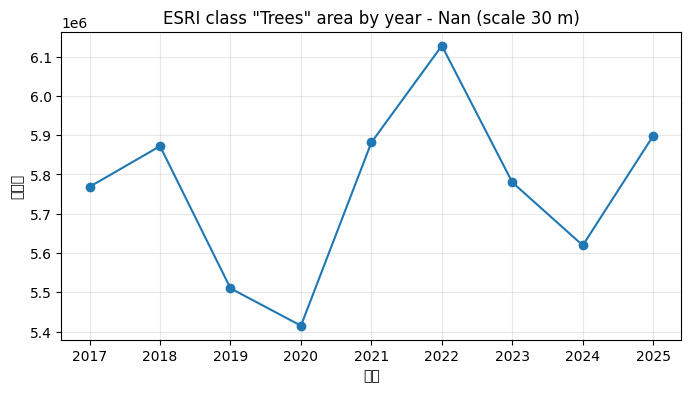

In [17]:
areas = ee.List([area_rai(trees(y).And(valid(y)).clip(prov_geom)) for y in years_int]).getInfo()
df_ts = pd.DataFrame({'ปี': years_int, 'พื้นที่ป่า (ไร่)': [round(a) for a in areas]})
df_ts['เปลี่ยนจากปีก่อน (ไร่)'] = df_ts['พื้นที่ป่า (ไร่)'].diff().fillna(0).astype(int)
display(df_ts)

ax = df_ts.plot(x='ปี', y='พื้นที่ป่า (ไร่)', marker='o', figsize=(8, 4),
                                title=f'ESRI class "Trees" area by year - {PROVINCE} (scale {SCALE} m)', legend=False)
ax.set_ylabel('Area (rai)'); ax.grid(alpha=.3)

## 12. ตรวจสอบผลด้วยตา (visual validation)

สุ่มจุดจากพื้นที่ที่เราบอกว่า "ป่าหาย" มา 15 จุด แล้วสร้างลิงก์ Google Maps ภาพดาวเทียมไว้เปิดดู
นี่คือการตรวจแบบเร็วที่สุดที่ทำได้โดยไม่มีข้อมูลภาคสนาม และเป็นคำตอบของคำถามข้อ 2 (วิธีตรวจสอบ)

ให้เปิดดูสัก 10 จุด แล้วจดว่า *ถูกกี่จุด* — ตัวเลขนี้ยังไม่ใช่ accuracy ทางสถิติที่สมบูรณ์
(ไม่ได้สุ่มแบบ stratified ทั้งภาพ ไม่มี confidence interval) แต่บอกทิศทางได้

In [16]:
N_SAMPLE = 15
pts = loss_f.selfMask().rename('cls').stratifiedSample(
    numPoints=N_SAMPLE, classBand='cls', region=prov_geom,
    scale=10, geometries=True, seed=42, tileScale=4)

feats = pts.getInfo()['features']
rows = []
for i, f in enumerate(feats, 1):
    lon, lat = f['geometry']['coordinates']
    rows.append({'จุดที่': i, 'lat': round(lat, 5), 'lon': round(lon, 5),
                 'ลิงก์ภาพดาวเทียม': f'https://www.google.com/maps/@{lat},{lon},400m/data=!3m1!1e3'})
df_check = pd.DataFrame(rows)
pd.set_option('display.max_colwidth', None)
display(df_check)
print('เปิดลิงก์ทีละจุด แล้วบันทึกว่า "ป่าหายจริง / ไม่จริง / ไม่แน่ใจ" ลงในใบตอบ')

,จุดที่,lat,lon,ลิงก์ภาพดาวเทียม
0,1,19.48693,101.03653,"https://www.google.com/maps/@19.48692887958375,101.03652936112438,400m/data=!3m1!1e3"
1,2,18.57505,100.68744,"https://www.google.com/maps/@18.575049034674024,100.68744404171554,400m/data=!3m1!1e3"
2,3,18.53471,100.44400,"https://www.google.com/maps/@18.534714678417057,100.44400059971915,400m/data=!3m1!1e3"
3,4,18.84356,100.70936,"https://www.google.com/maps/@18.84355547309735,100.70936293464806,400m/data=!3m1!1e3"
4,5,19.39925,101.03833,"https://www.google.com/maps/@19.399253307853684,101.03832599169262,400m/data=!3m1!1e3"
5,6,19.12832,100.83342,"https://www.google.com/maps/@19.128321418163235,100.83342027538495,400m/data=!3m1!1e3"
6,7,19.27394,100.61486,"https://www.google.com/maps/@19.273938325719012,100.61486016675867,400m/data=!3m1!1e3"
7,8,19.40931,100.99907,"https://www.google.com/maps/@19.409314439035825,100.9990696137766,400m/data=!3m1!1e3"
8,9,18.56310,101.03033,"https://www.google.com/maps/@18.563101441395233,101.03033098566395,400m/data=!3m1!1e3"
9,10,18.52070,100.62654,"https://www.google.com/maps/@18.520700959984794,100.62653826545223,400m/data=!3m1!1e3"


เปิดลิงก์ทีละจุด แล้วบันทึกว่า "ป่าหายจริง / ไม่จริง / ไม่แน่ใจ" ลงในใบตอบ


## 13. (ทางเลือก) ส่งออกผลลัพธ์

ถ้าต้องการเอาไปทำแผนที่ต่อใน QGIS / ArcGIS ให้ uncomment เซลล์นี้
`Export` เป็นงาน background ต้องไปกด Run ที่แท็บ Tasks ของ Code Editor หรือรอใน Drive

In [ ]:
# task = ee.batch.Export.image.toDrive(
#     image=loss_f.selfMask().byte(),
#     description=f'forest_loss_{PROVINCE}_{YEAR_A}_{YEAR_B}',
#     folder='GE439_Lab2',
#     region=prov_geom,
#     scale=10, maxPixels=1e13)
# task.start()
# print('ส่งงาน export แล้ว | status:', task.status()['state'])

# df_loss_to.to_csv(f'loss_transition_{PROVINCE}.csv', index=False, encoding='utf-8-sig')

## 14. ข้อจำกัดของงานชิ้นนี้ (เขียนไว้ตรง ๆ)

**ข้อจำกัดของข้อมูล**

1. ESRI/IO LULC รายงาน accuracy เฉลี่ยทั่วโลกราว 75%+ ซึ่งเป็นค่าระดับ **โลก** ไม่ใช่ค่าเฉพาะประเทศไทยหรือจังหวัดที่เลือก — โน้ตบุ๊กนี้ **ไม่ได้ตรวจสอบ** accuracy ในพื้นที่ศึกษา
2. error ของแผนที่ 2 ปี **สะสมกันเมื่อเอามาลบกัน** พื้นที่ที่แจ้งว่าเปลี่ยนแปลงจึงมี error สูงกว่าแผนที่รายปีเสมอ โดยเฉพาะเมื่อสัดส่วนการเปลี่ยนแปลงจริงน้อยกว่าอัตรา error
3. คลาส `Trees` ≠ ป่าตามนิยามกฎหมาย รวมยางพารา ปาล์ม สวนผลไม้ ป่าปลูก → เทียบกับสถิติกรมป่าไม้ตรง ๆ ไม่ได้
4. ปีของแต่ละภาพเป็น **composite ทั้งปี** ไม่ใช่ภาพ ณ วันใดวันหนึ่ง จึงระบุ "เดือนที่เกิดเหตุ" ไม่ได้
5. ขอบเขตจังหวัดจาก FAO GAUL 2015 เป็นข้อมูลปี 2015 ที่ generalize มาแล้ว (โดยเฉพาะเวอร์ชัน simplified 500 m) พื้นที่รวมจึงไม่ตรงกับขอบเขตราชการเป๊ะ ๆ

**ข้อจำกัดของวิธีในโน้ตบุ๊กนี้**

6. ค่า `MIN_PIXELS`, `STRICT`, `SCALE` เป็นการ **เลือกโดยดุลพินิจ** ไม่ได้ปรับจูนด้วยข้อมูลอ้างอิง เปลี่ยนค่าแล้วตัวเลขเปลี่ยน — จึงต้องรายงานคู่กับตัวเลขเสมอ
7. การตรวจสอบในหัวข้อ 12 เป็นการดูภาพด้วยตาจากจุดสุ่มจำนวนน้อย **ไม่ใช่** การประเมินความถูกต้องตามมาตรฐาน (ไม่มี confusion matrix, ไม่มี stratified design, ไม่มีช่วงความเชื่อมั่น) และภาพฐานของ Google เป็นภาพคนละวันกับข้อมูล
8. ไม่ได้เทียบกับชุดข้อมูลอิสระอื่น (เช่น Dynamic World, Hansen Global Forest Change, JAXA) ซึ่งจะเป็นการตรวจสอบที่แข็งแรงกว่ามาก
9. `connectedPixelCount` มีเพดาน `maxSize` (patch ใหญ่จะถูกนับตันที่เพดาน — ไม่กระทบผลเพราะเราสนใจแค่ว่า >= MIN_PIXELS) และผลของ MMU ขึ้นกับ scale ที่ร้องขอ ตัวเลขกับภาพบนแผนที่จึงอาจต่างกันเล็กน้อยตามที่อธิบายในหัวข้อ 7
10. ถ้าเซลล์คำนวณพื้นที่หมดเวลา (`Computation timed out`) ให้เพิ่มค่า `SCALE` หรือใช้ `ee.batch.Export` แทน แล้วบันทึกไว้ในใบตอบว่าใช้ scale เท่าไร

**สิ่งที่ยังไม่ได้ยืนยัน (unverified)**

* โน้ตบุ๊กนี้รันจริงบนบัญชี GEE เมื่อวันที่จัดทำรายงาน ได้ผลตามที่แสดงในเซลล์ด้านบน แต่ **ยังไม่ได้ตรวจสอบความถูกต้องเชิงสถิติ** ตัวเลขทั้งหมดจึงเป็นค่าประมาณที่ยังไม่มีช่วงความเชื่อมั่น
* จำนวนปีที่ collection มีให้ ณ วันที่รันคือ 2017–2025 (9 ปี ปีละ 6 tile ที่ครอบคลุมไทย) ผู้ดูแลแคตตาล็อกเพิ่มปีใหม่เป็นระยะ การรันซ้ำภายหลังอาจได้จำนวนปีต่างออกไป ให้เชื่อผลจากเซลล์ตรวจสอบความพร้อมใช้เป็นหลัก
* ผลการตรวจสอบด้วยสายตาจาก 15 จุดในหัวข้อ 12 ยังไม่ได้บันทึกลงในโน้ตบุ๊ก ต้องเปิดลิงก์ตรวจเองแล้วกรอกผลในใบตอบ

# คำถามท้ายบทปฏิบัติการ — คำตอบ

**พารามิเตอร์ที่ใช้ตอบทุกข้อ:** จังหวัด Nan | ช่วงปี 2017 → 2025 | SCALE = 30 m | STRICT = True (ต้องสอดคล้อง 2 ปีติดกันที่หัวและท้ายช่วง) | MMU = 5 pixels | geemap 0.38.3
ถ้าเปลี่ยนพารามิเตอร์เหล่านี้ ตัวเลขจะเปลี่ยน จึงต้องรายงานควบคู่กันเสมอ

| ตัวเลขที่ใช้อ้างอิง | ค่า |
|---|---|
| พื้นที่จังหวัด (ขอบเขต GAUL) | 7,673,358 ไร่ |
| พื้นที่ Trees ปี 2017 | 5,768,524 ไร่ (75.2%) |
| พื้นที่ Trees ปี 2025 | 5,898,434 ไร่ (76.9%) |
| ป่าหาย — วิธีเดิม / วิธีคัดกรอง | 340,101 / **164,201** ไร่ |
| ป่าเพิ่ม — วิธีเดิม / วิธีคัดกรอง | 470,011 / **161,843** ไร่ |
| ความผันผวนรายปี (mean \|Δ\|) | 257,498 ไร่ (sd = 218,830 ไร่ = 3.8% ของค่าเฉลี่ย) |

---

## ข้อ 1 — ป่าหายหรือป่าเพิ่มมากกว่ากัน กลายเป็นคลาสอะไร และบอกอะไรเรื่อง driver

จังหวัดน่านระหว่างปี 2017 ถึง 2025 มีพื้นที่ป่าหาย **164,201 ไร่** และป่าเพิ่ม **161,843 ไร่** คิดเป็นอัตราส่วน **1.01 : 1** คือเกือบเท่ากันพอดี พื้นที่ป่าหายคิดเป็น 2.85% ของพื้นที่ป่าตั้งต้น การเปลี่ยนแปลงสุทธิจากการตรวจจับเชิงจุดภาพเท่ากับ −2,358 ไร่ (ป่าหายมากกว่าเล็กน้อย)

ป่าที่หายไปกลายเป็นคลาส **Rangeland มากที่สุด 127,236 ไร่ (77.5%)** รองลงมาคือ Crops 28,122 ไร่ (17.1%) และ Built Area 8,006 ไร่ (4.9%)

**แต่ตัวเลขนี้ตีความเป็น driver ตรง ๆ ไม่ได้** เพราะตารางทิศทางย้อนกลับแสดงว่าป่าที่เพิ่มขึ้น 92.9% (150,315 ไร่) ก็มีต้นทางเป็นคลาส Rangeland เช่นเดียวกัน การแลกเปลี่ยน Trees ↔ Rangeland จึงเกิดขึ้นสองทิศในปริมาณใกล้เคียงกัน (127,236 เทียบกับ 150,315 ไร่) ซึ่งเป็นรูปแบบที่คาดหวังจากความสับสนของแบบจำลองที่เส้นแบ่งระหว่างคู่คลาสที่มีลักษณะสเปกตรัมใกล้กัน มากกว่าจะเป็นการทำลายป่าและการฟื้นฟูป่าที่บังเอิญเกิดพร้อมกันในปริมาณเท่ากันภายในจังหวัดเดียว

driver ที่มีหลักฐานหนักแน่นกว่าคือคลาสที่การเปลี่ยนแปลง **ไม่สมมาตร**

| คลาส | ป่า → คลาสนี้ | คลาสนี้ → ป่า | สุทธิ | การตีความ |
|---|---|---|---|---|
| Rangeland | 127,236 | 150,315 | +23,079 | สมมาตร → ส่วนใหญ่เป็น model confusion |
| Crops | 28,122 | 10,787 | −17,335 | การขยายพื้นที่เกษตรจริง (พืชไร่บนที่ลาดชัน) |
| Built Area | 8,006 | 431 | −7,575 | การขยายชุมชน/โครงสร้างพื้นฐาน เชื่อถือได้ที่สุด |

สรุปคือ driver ที่อ่านได้จากข้อมูลนี้อย่างมั่นใจคือ **การขยายพื้นที่เกษตรประมาณ 17,000 ไร่ และการขยายพื้นที่สิ่งปลูกสร้างประมาณ 7,600 ไร่** ส่วนตัวเลขก้อนใหญ่ 127,236 ไร่ ที่ "กลายเป็น Rangeland" ต้องถือว่ายังพิสูจน์ไม่ได้ว่าเป็นการเปลี่ยนแปลงจริง

---

## ข้อ 2 — "ป่าเพิ่ม" ที่อาจเป็นสิ่งลวง (artifact) 2 สาเหตุ พร้อมวิธีตรวจสอบ

### สาเหตุที่ 1: ความสับสนระหว่างคลาสที่มีลักษณะสเปกตรัมใกล้เคียงกัน (Rangeland/Crops ↔ Trees)

พืชไร่ที่โตเต็มที่ ไม้พุ่มที่กำลังฟื้นตัว ไร่หมุนเวียนที่พักฟื้น และสวนยางอายุน้อย ให้ค่าการสะท้อนใกล้เคียงเรือนยอดไม้มาก เมื่อภาพ composite ของปีใดปีหนึ่งบังเอิญเลือกช่วงที่พืชพรรณหนาแน่นที่สุด พื้นที่ที่เดิมเป็น Rangeland จะถูกจัดเป็น Trees ทำให้เห็นเป็น "ป่าเพิ่ม" ทั้งที่ไม่มีต้นไม้เพิ่มขึ้นจริง

หลักฐานเชิงตัวเลขในแลปนี้:
- ป่าเพิ่ม 92.9% มีต้นทางเป็น Rangeland
- อนุกรมเวลารายปีแกว่งรุนแรงมาก ปี 2020 → 2021 พื้นที่ Trees **เพิ่มขึ้น 466,462 ไร่ ภายในปีเดียว** ซึ่งเป็นอัตราที่เป็นไปไม่ได้ทางนิเวศวิทยา เพราะป่าที่ตรวจจับได้จากดาวเทียมต้องใช้เวลาเติบโตหลายปี

**วิธีตรวจสอบ**
1. ดูอนุกรมเวลาทั้ง 9 ปี (หัวข้อ 11 ของโน้ตบุ๊ก) ถ้าจุดภาพเดียวกันสลับ Trees/Rangeland ไปมาหลายรอบ = การกระพริบของแบบจำลอง ไม่ใช่การปลูกป่า เพราะป่าจริงเมื่อขึ้นแล้วไม่หายในปีถัดมา
2. บังคับเงื่อนไข STRICT ให้ต้องเป็นป่าสอดคล้องกัน 2 ปีติด แล้ววัดว่าตัวเลขลดลงเท่าไร — ในแลปนี้พื้นที่ป่าเพิ่ม**ลดลง 65.6%** (จาก 470,011 เหลือ 161,843 ไร่) ส่วนที่หายไปคือขนาดของ artifact ที่วัดได้จริง ไม่ใช่การเดา
3. สุ่มจุดในพื้นที่ gain แล้วเปิดภาพดาวเทียมความละเอียดสูงดูว่าเห็นเรือนยอดไม้จริงหรือไม่ (ใช้โค้ดหัวข้อ 12 โดยเปลี่ยน `loss_f` เป็น `gain_f`)

### สาเหตุที่ 2: เมฆ เงาเมฆ และความไม่สมบูรณ์ของข้อมูลตั้งต้นในปีฐาน

ประเทศไทยมีเมฆปกคลุมหนาในช่วงมรสุม ถ้าจุดภาพใดในปี 2017 ถูกทำนายเป็นคลาส Clouds (รหัส 10) หรือถูกเงาเมฆทำให้ค่าการสะท้อนต่ำจนถูกจัดเป็นคลาสอื่น แล้วปี 2025 ข้อมูลมีคุณภาพดีขึ้นจนจำแนกเป็น Trees ได้ จุดภาพนั้นจะถูกนับเป็น "ป่าเพิ่ม" ทั้งที่เป็นป่าเดิมมาตลอด

โค้ดตั้งต้นที่ใช้เงื่อนไข `first.neq(2).And(last.eq(2))` นับกรณีนี้เป็นการเปลี่ยนแปลงเต็มจำนวน เพราะ `neq(2)` เป็นจริงกับคลาส Clouds และกับข้อมูลว่างด้วย

**วิธีตรวจสอบ**
1. เพิ่ม valid mask ตัดคลาส 10 และค่า 0 ออกจากทั้งสองปีก่อนเปรียบเทียบ แล้ววัดว่าพื้นที่ gain ลดลงเท่าไร ส่วนที่หายไปคือ artifact ที่เคยถูกนับ
2. ทำแผนที่นับจำนวนปีที่แต่ละจุดภาพถูกจำแนกเป็น Clouds ถ้าพื้นที่ gain กระจุกตัวทับกับบริเวณที่มีเมฆบ่อย = สัญญาณเตือนชัดเจน

### สาเหตุที่ 3 (เสริม): จุดภาพผสมบริเวณขอบแปลง

ที่ความละเอียด 10 เมตร ขอบระหว่างป่ากับแปลงเกษตรเป็นจุดภาพผสม ผลการจำแนกจึงแกว่งไปมาระหว่างปี เกิดเป็นแนว gain/loss บาง ๆ ตามขอบแปลง ตรวจสอบได้จากรูปร่าง ถ้าเป็นเส้นกว้าง 1–2 จุดภาพเกาะขอบแปลงเดิม แทบไม่มีทางเป็นการปลูกป่าจริง การใส่ MMU แล้ววัดว่าตัวเลขลดลงกี่เปอร์เซ็นต์คือการวัดขนาดของปัญหานี้ (ในแลปนี้ loss ลดลง 51.7%)

---

## ข้อ 3 — หมายเหตุกำกับตัวเลข (caveat) สำหรับการแถลงข่าว

> ตัวเลขนี้ประมาณจากแผนที่สิ่งปกคลุมดินความละเอียด 10 เมตร ที่จำแนกด้วยแบบจำลอง AI (Esri/Impact Observatory) ซึ่งผู้ผลิตรายงานความถูกต้องเฉลี่ยระดับโลกมากกว่า 75% และยังไม่ได้ประเมินความถูกต้องเฉพาะพื้นที่จังหวัดน่าน จึงเป็น **ตัวบ่งชี้แนวโน้มเพื่อคัดกรองพื้นที่ที่ควรเข้าตรวจสอบ ไม่ใช่ตัวเลขทางการ** และใช้อ้างอิงเชิงคดีไม่ได้
>
> คำว่า "ป่า" ในที่นี้หมายถึงพื้นที่ที่มีเรือนยอดไม้ ซึ่งรวมสวนยางพารา ปาล์ม ไม้ผล และป่าปลูก จึงไม่ตรงกับนิยามป่าไม้ตามกฎหมาย และใช้แทนสถิติของกรมป่าไม้ไม่ได้
>
> ผลลัพธ์ขึ้นกับปีที่เลือกเปรียบเทียบและเกณฑ์กรองสัญญาณรบกวน จากข้อมูลชุดเดียวกันนี้ค่าที่รายงานได้อยู่ระหว่าง **99,150 ถึง 340,101 ไร่** ขึ้นกับพารามิเตอร์ที่เลือก หากจะใช้ประกอบการตัดสินใจเชิงนโยบาย ควรตรวจสอบซ้ำด้วยภาพความละเอียดสูงและการสำรวจภาคสนามในพื้นที่ที่ระบุก่อน

---

## ข้อสังเกตเพิ่มเติมจากการทำแลป

1. **สัญญาณจมอยู่ใต้ noise** — ความผันผวนของพื้นที่ Trees ปีต่อปีเฉลี่ย 257,498 ไร่ สูงกว่าการเปลี่ยนแปลงสุทธิตลอด 9 ปี (129,910 ไร่) เกือบสองเท่า การเปรียบเทียบเพียง 2 ปีตามโค้ดตั้งต้นจึงเป็นการหยิบ 2 จุดจากอนุกรมที่แปรปรวนสูง เลือกคนละคู่ปีจะได้ข้อสรุปคนละทิศทางจากข้อมูลชุดเดียวกัน
2. **สองวิธีให้ทิศทางสุทธิขัดกัน** — การนำพื้นที่ป่ารายปีมาลบกันได้ +129,910 ไร่ (เพิ่มขึ้น) แต่การตรวจจับการเปลี่ยนแปลงเชิงจุดภาพแบบคัดกรองได้ −2,358 ไร่ (ลดลง) เพราะเงื่อนไข STRICT คัดจุดภาพที่เปลี่ยนสถานะในปี 2018 หรือ 2024 ออกจากทั้งสองหมวด ขณะที่จุดภาพเหล่านั้นยังถูกนับในผลรวมรายปี
3. **ทิศทางสุทธิยังกลับด้านตาม scale** — ที่ 100 m ได้ป่าเพิ่มมากกว่าป่าหาย 1,332 ไร่ แต่ที่ 30 m และ 10 m ได้ป่าหายมากกว่าป่าเพิ่ม 2,358 และ 2,413 ไร่ ตามลำดับ ข้อสรุปเชิงทิศทางจึงเปลี่ยนได้ด้วยพารามิเตอร์ทางเทคนิคเพียงตัวเดียว
4. **ตัวเลขที่น่าเชื่อถือที่สุดคือ Built Area** — 8,006 ไร่ ที่เปลี่ยนจากป่าเป็นสิ่งปลูกสร้าง มีทิศทางย้อนกลับเพียง 431 ไร่ ความไม่สมมาตรนี้สอดคล้องกับความจริงทางกายภาพว่าพื้นที่ก่อสร้างไม่กลับไปเป็นป่าในเวลาสั้น ๆ

*แนบลิงก์ Colab ที่รันได้จริง + คำตอบทั้ง 3 ข้อ ส่งใน Google Classroom*